<a href="https://colab.research.google.com/github/favouregberike/modeling-financial-exclusion-africa/blob/main/financial_inclusion_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning & Initial Exploration

In [ ]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('WB_FINDEX.csv')
# Preview first 5 rows to understand structure
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,UNIT_TYPE_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,DATA_SOURCE_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,ZMB,WB_FINDEX_FH1_FH2,_T,Y_GE15,RUR,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,ZMB,WB_FINDEX_FH1_FH2,_T,Y_GE15,URB,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,ZWE,WB_FINDEX_FH1_FH2,_T,Y_GE15,RUR,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,ZWE,WB_FINDEX_FH1_FH2,_T,Y_GE15,URB,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,AFG,WB_FINDEX_FH1_FH2,_T,Y_GE15,_T,PT_RESP,...,Total,Employment: Out of the workforce/labor force,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public


In [77]:
# DATA STRUCTURE OVERVIEW
# Check dataset shape (rows, columns)
print("Shape:", df.shape)

# List all columns
print(df.columns.tolist())

# Get dataset information (data types + missing values)
df.info()

df.head()

Shape: (27466, 7)
['country', 'gender', 'age_group', 'urbanization', 'indicator', 'year', 'value']
<class 'pandas.core.frame.DataFrame'>
Index: 27466 entries, 0 to 27465
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       27466 non-null  object 
 1   gender        27466 non-null  object 
 2   age_group     27466 non-null  object 
 3   urbanization  27466 non-null  object 
 4   indicator     27466 non-null  object 
 5   year          27466 non-null  int64  
 6   value         27466 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.7+ MB


,country,gender,age_group,urbanization,indicator,year,value
0,Zambia,Total,15 years old and over,Rural area,Sent or received domestic remittances,2024,63.962717
1,Zambia,Total,15 years old and over,Urban area,Sent or received domestic remittances,2024,69.993418
2,Zimbabwe,Total,15 years old and over,Rural area,Sent or received domestic remittances,2024,47.785261
3,Zimbabwe,Total,15 years old and over,Urban area,Sent or received domestic remittances,2024,63.229884
4,Afghanistan,Total,15 years old and over,Total,Sent or received domestic remittances,2021,15.559451


In [ ]:
# SELECT RELEVANT COLUMNS FOR ANALYSIS
# We keep only columns relevant for financial exclusion analysis

df = df[[
    'REF_AREA_LABEL',          # Country
    'SEX_LABEL',               # Gender
    'AGE_LABEL',               # Age group
    'URBANISATION_LABEL',      # Urban vs rural
    'INDICATOR_LABEL',         # Financial indicator type
    'TIME_PERIOD',             # Year
    'OBS_VALUE'                # Value (target variable)
]]

In [75]:
# RENAME COLUMNS FOR EASIER HANDLING
df.columns = [
    'country',
    'gender',
    'age_group',
    'urbanization',
    'indicator',
    'year',
    'value'
]

df.head()

,country,gender,age_group,urbanization,indicator,year,value
0,Zambia,Total,15 years old and over,Rural area,Sent or received domestic remittances,2024,63.962717
1,Zambia,Total,15 years old and over,Urban area,Sent or received domestic remittances,2024,69.993418
2,Zimbabwe,Total,15 years old and over,Rural area,Sent or received domestic remittances,2024,47.785261
3,Zimbabwe,Total,15 years old and over,Urban area,Sent or received domestic remittances,2024,63.229884
4,Afghanistan,Total,15 years old and over,Total,Sent or received domestic remittances,2021,15.559451


In [76]:
# CHECK AND HANDLE MISSING VALUES
# Check missing values in each column
print(df.isnull().sum())

# Drop missing values for simplicity
# (alternative: imputation could also be used)
df = df.dropna()

print("Shape after cleaning:", df.shape)

country         0
gender          0
age_group       0
urbanization    0
indicator       0
year            0
value           0
dtype: int64
Shape after cleaning: (27466, 7)


African Country Filtering

This project focuses specifically on financial exclusion patterns across African populations.
filtered the dataset to include only African countries.

In [80]:
# AFRICAN COUNTRIES LIST
african_countries = [
    "Algeria", "Angola", "Benin", "Botswana",
    "Burkina Faso", "Burundi", "Cabo Verde",
    "Cameroon", "Central African Republic",
    "Chad", "Comoros", "Côte d’Ivoire",
    "Democratic Republic of the Congo",
    "Djibouti", "Egypt", "Equatorial Guinea",
    "Eritrea", "Eswatini", "Ethiopia",
    "Gabon", "Gambia", "Ghana", "Guinea",
    "Guinea-Bissau", "Kenya", "Lesotho",
    "Liberia", "Libya", "Madagascar",
    "Malawi", "Mali", "Mauritania",
    "Mauritius", "Morocco", "Mozambique",
    "Namibia", "Niger", "Nigeria",
    "Republic of the Congo", "Rwanda",
    "São Tomé and Príncipe", "Senegal",
    "Seychelles", "Sierra Leone",
    "Somalia", "South Africa",
    "South Sudan", "Sudan", "Tanzania",
    "Togo", "Tunisia", "Uganda",
    "Zambia", "Zimbabwe"
]

# STANDARDIZE COUNTRY NAMES
df['country'] = df['country'].replace({
    "Benin (Dahomey)": "Benin",
    "Côte d’Ivoire (Ivory Coast)": "Côte d’Ivoire",
    "The Gambia": "Gambia"
})

# FILTER AFRICAN COUNTRIES
africa_df = df[
    df['country'].isin(african_countries)
].copy()

print("Africa Dataset Shape:", africa_df.shape)

Africa Dataset Shape: (10006, 7)


# Exploratory Data Analysis(EDA)

Financial Exclusion Indicators

Isolate exclusion-related indicators to better understand barriers to financial access.

In [83]:
# FILTER FINANCIAL EXCLUSION INDICATORS
exclusion_df = africa_df[
    africa_df['indicator'].str.contains(
        'No account',
        case=False,
        na=False
    )
]



Financial Exclusion by Country

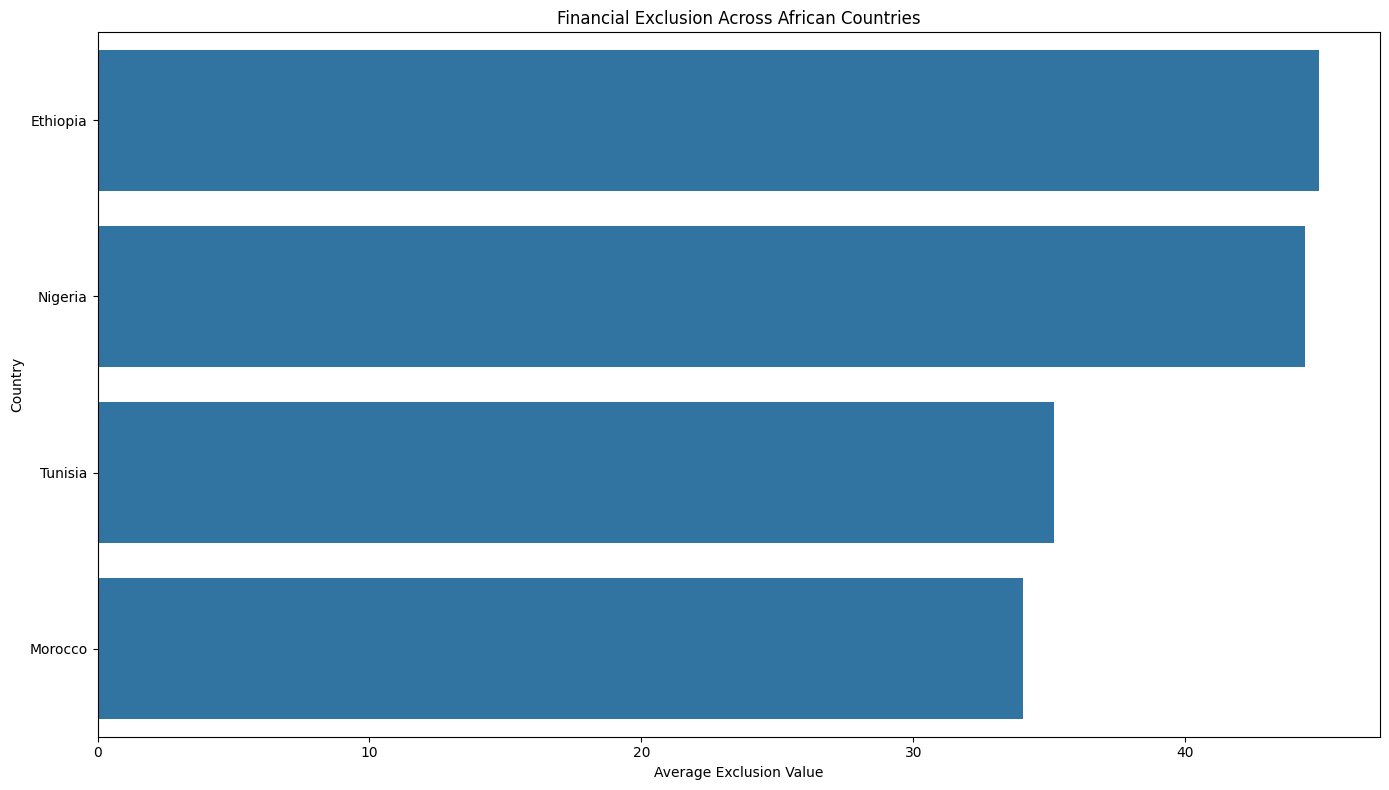

In [84]:
# COUNTRY-LEVEL EXCLUSION ANALYSIS
country_exclusion = (
    exclusion_df
    .groupby('country')['value']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=country_exclusion.values,
    y=country_exclusion.index
)

plt.title('Financial Exclusion Across African Countries')
plt.xlabel('Average Exclusion Value')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

Gender Analysis Across Africa

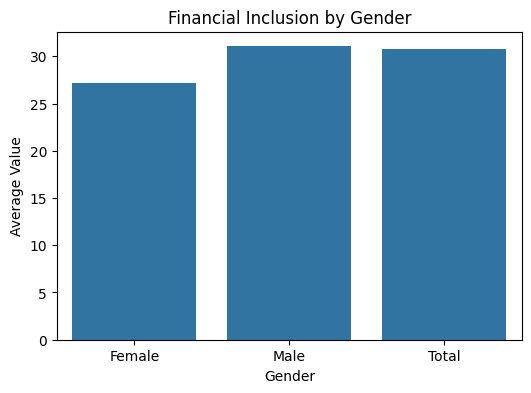

In [85]:
# GENDER ANALYSIS
gender_analysis = (
    africa_df
    .groupby('gender')['value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=gender_analysis,
    x='gender',
    y='value'
)

plt.title('Financial Inclusion by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Value')

plt.show()

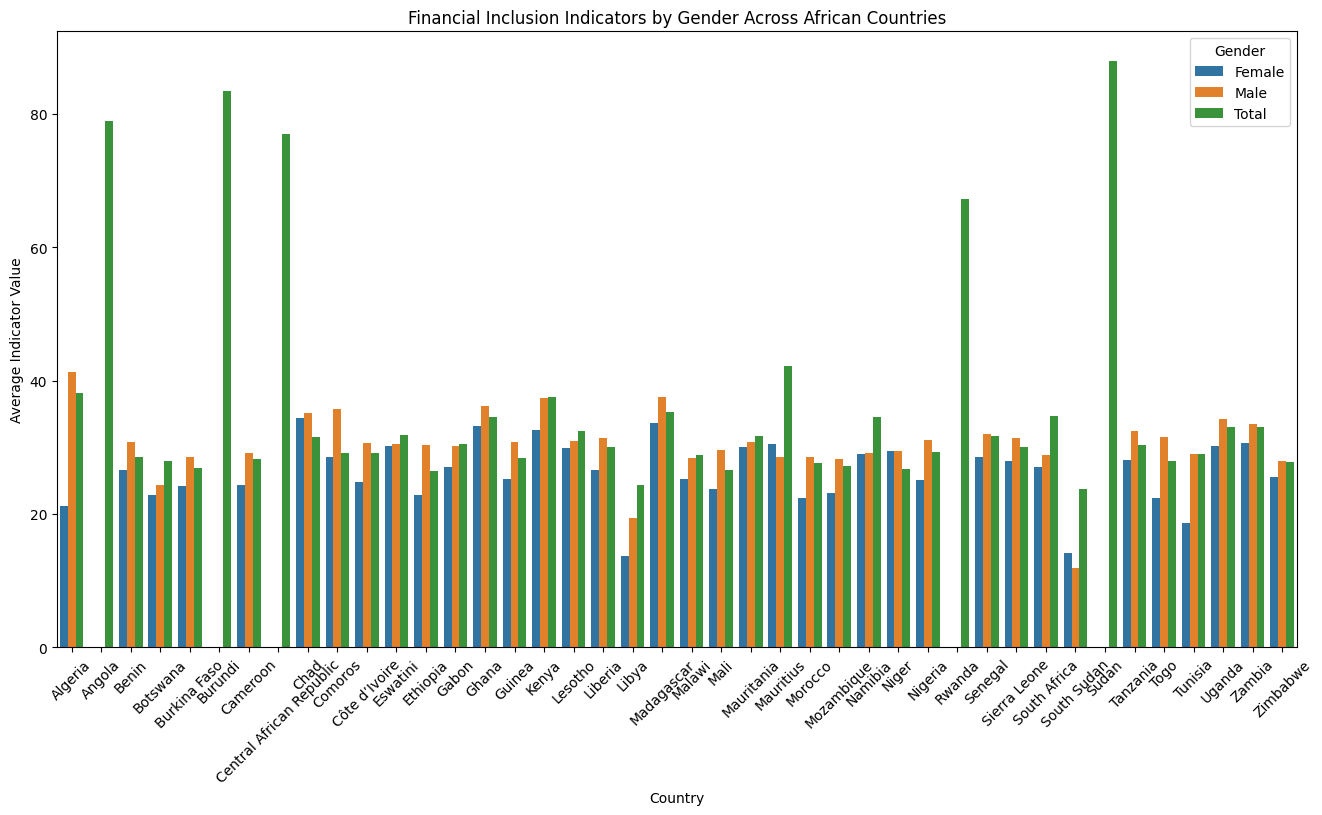

In [89]:

# Group by country and gender
gender_country_analysis = (
    africa_df
    .groupby(['country', 'gender'])['value']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(16,8))

sns.barplot(
    data=gender_country_analysis,
    x='country',
    y='value',
    hue='gender'
)

plt.title('Financial Inclusion Indicators by Gender Across African Countries')
plt.xlabel('Country')
plt.ylabel('Average Indicator Value')

plt.xticks(rotation=45)

plt.legend(title='Gender')

plt.show()

Top Financial Indicators in Africa

In [86]:
# TOP FINANCIAL INDICATORS
top_indicators = (
    africa_df
    .groupby('indicator')['value']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

top_indicators

,value
indicator,
Received public sector wages: into an account,91.470792
Received public sector wages: into a bank or similar financial institution account,87.953419
Received a public sector pension: into an account,77.734602
Received a public sector pension: into a bank or similar financial institution account,77.112233
Received payments for agricultural products: in cash only,76.566502
Received government transfer: into an account,73.940381
No account because of insufficient funds,73.657611
Made a digital online merchant payment for an online purchase,72.700643
Received government transfer: to a card,71.238471


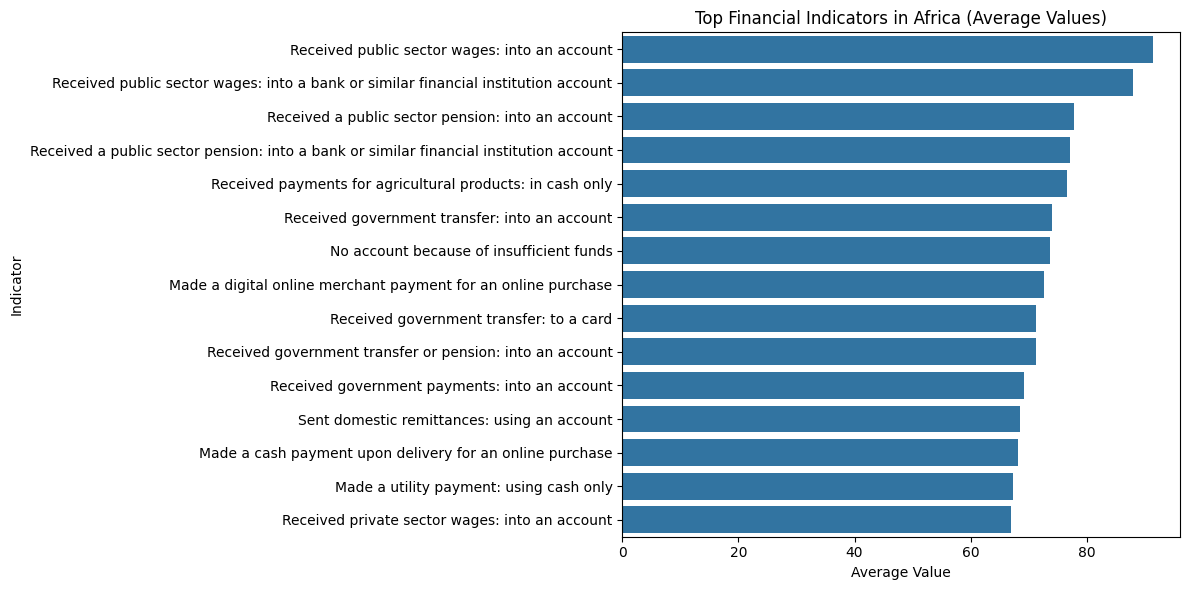

In [87]:
# VISUALIZE TOP INDICATORS

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_indicators.values,
    y=top_indicators.index
)

plt.title("Top Financial Indicators in Africa (Average Values)")
plt.xlabel("Average Value")
plt.ylabel("Indicator")

plt.tight_layout()
plt.show()

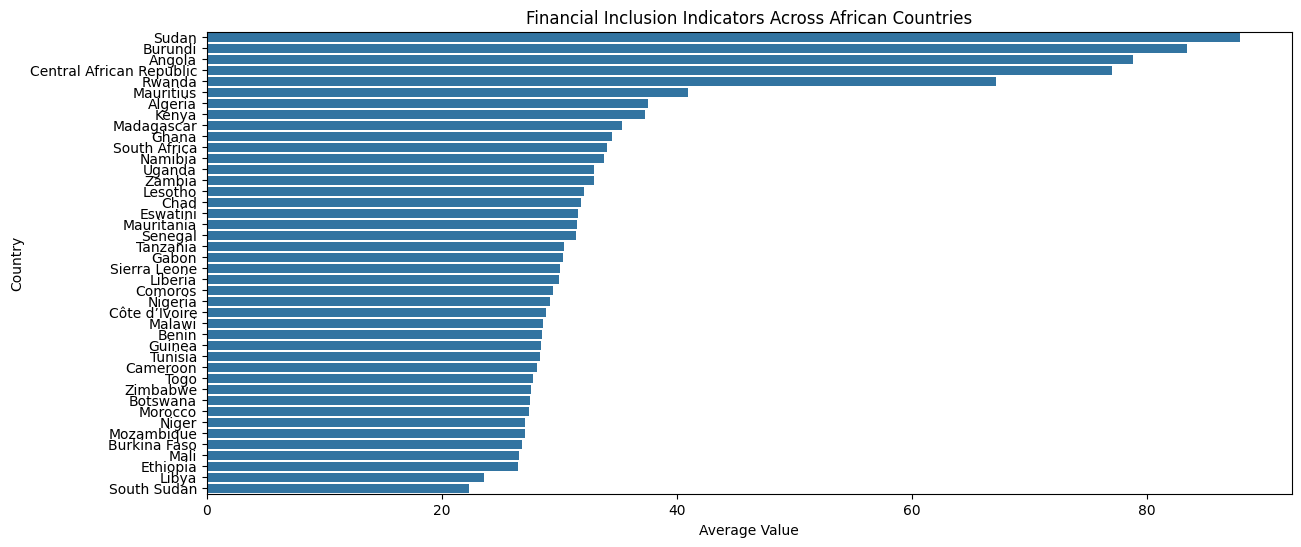

In [88]:
# AVERAGE FINANCIAL INDICATORS BY COUNTRY
country_analysis = (
    africa_df
    .groupby('country')['value']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=country_analysis.values,
    y=country_analysis.index
)

plt.title("Financial Inclusion Indicators Across African Countries")
plt.xlabel("Average Value")
plt.ylabel("Country")

plt.show()

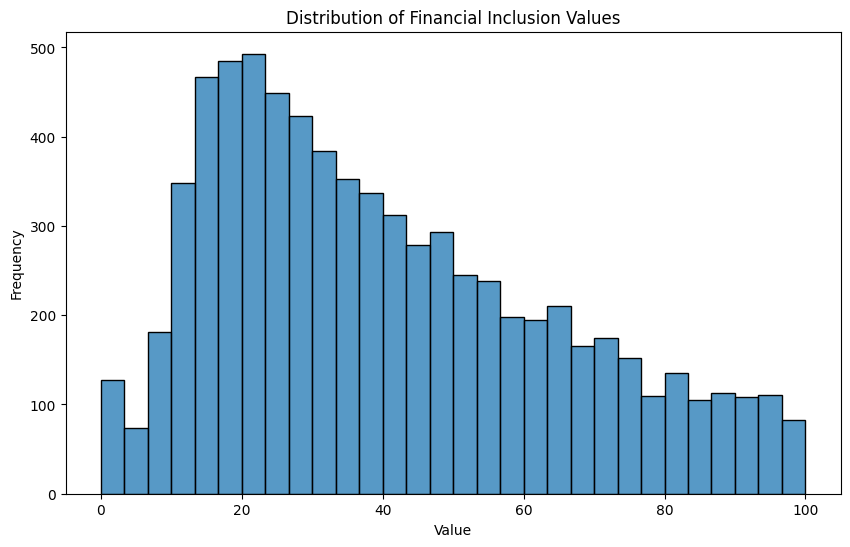

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(filtered_df['value'], bins=30)

plt.title('Distribution of Financial Inclusion Values')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

In [91]:
# FINANCIAL EXCLUSION INDICATORS
exclusion_keywords = [
    "No account",
    "insufficient funds",
    "too far",
    "lack of trust",
    "lack of documentation"
]

exclusion_df = africa_df[
    africa_df['indicator'].str.contains('|'.join(exclusion_keywords), case=False, na=False)
]

top_exclusion = (
    exclusion_df
    .groupby('indicator')['value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_exclusion

,value
indicator,
No account because of insufficient funds,73.657611
No account because someone in the family has one,32.181119
No account because bank or similar financial institutions are too far away,31.630783
No account because of a lack of necessary documentation,30.984156
No account because of a lack of trust in bank or similar financial institutions,24.807882
No account because financial services are too expensive,19.442009


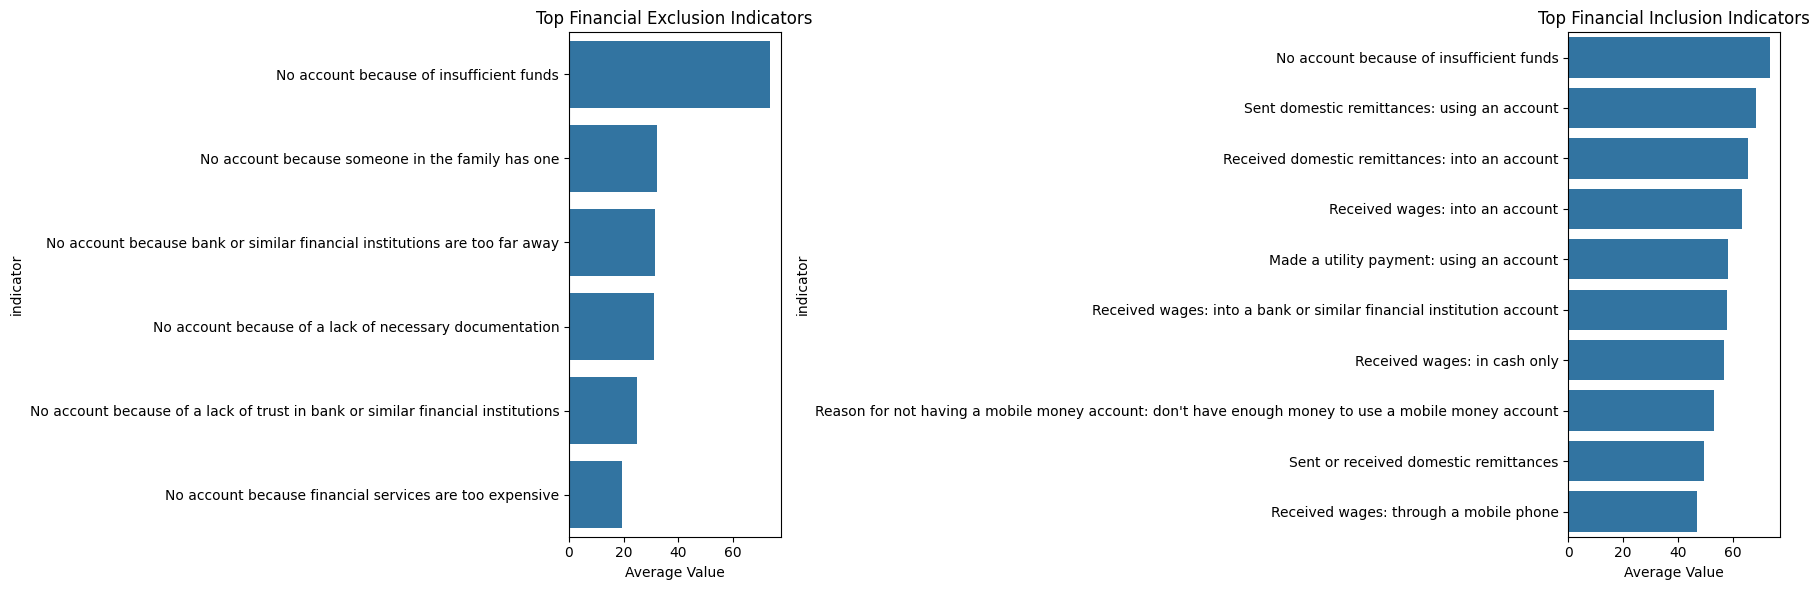

In [95]:
# COMPARISON: INCLUSION VS EXCLUSION
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Exclusion indicators
sns.barplot(
    x=top_exclusion.values,
    y=top_exclusion.index,
    ax=axes[0]
)
axes[0].set_title("Top Financial Exclusion Indicators")
axes[0].set_xlabel("Average Value")

# Inclusion indicators
sns.barplot(
    x=top_inclusion.values,
    y=top_inclusion.index,
    ax=axes[1]
)
axes[1].set_title("Top Financial Inclusion Indicators")
axes[1].set_xlabel("Average Value")

plt.tight_layout()
plt.show()

# Feature Engineering for Machine Learning (Africa Only)

In [97]:
# CREATE MODELING DATASET
model_df = africa_df.copy()

features = [
    'country',
    'gender',
    'age_group',
    'urbanization',
    'indicator',
    'year'
]

target = 'value'

X = model_df[features].copy()
y = model_df[target]

In [98]:
# ENCODE CATEGORICAL VARIABLES
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'country',
    'gender',
    'age_group',
    'urbanization',
    'indicator'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X[col] = le.fit_transform(X[col].astype(str))

    encoders[col] = le

In [111]:
# SPLIT DATA FOR MODEL TRAINING
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8004, 6)
Testing Shape: (2002, 6)


In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8004, 6)
(2002, 6)
(8004,)
(2002,)


# Machine Learning Modeling


 Linear Regression Model (Baseline Model)
Build a baseline machine learning model using Linear Regression.

In [112]:
# LINEAR REGRESSION MODEL
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Linear Regression Results")
print("_____________________")

print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", mean_squared_error(y_test, lr_preds) ** 0.5)
print("R²:", r2_score(y_test, lr_preds))

Linear Regression Results
_____________________
MAE: 14.402046883341166
RMSE: 17.916572037262576
R²: 0.1815604760640448


RANDOM FOREST REGRESSION MODEL

In [113]:

# RANDOM FOREST REGRESSOR
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Results")
print("____________________")

print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", mean_squared_error(y_test, rf_preds) ** 0.5)
print("R²:", r2_score(y_test, rf_preds))

Random Forest Results
____________________
MAE: 5.629423122550426
RMSE: 8.369493892527098
R²: 0.8214025937040824


XGBOOST REGRESSION MODEL

In [114]:
# XGBOOST REGRESSOR
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Results")
print("________________")

print("MAE:", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", mean_squared_error(y_test, xgb_preds) ** 0.5)
print("R²:", r2_score(y_test, xgb_preds))

XGBoost Results
________________
MAE: 7.546635512951488
RMSE: 10.03972363006428
R²: 0.7430076062242491


MODEL COMPARISON


In [115]:
# MODEL PERFORMANCE COMPARISON

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],

    'MAE': [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],

    'R²': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ]
})

results

,Model,MAE,R²
0,Linear Regression,14.402047,0.181560
1,Random Forest,5.629423,0.821403
2,XGBoost,7.546636,0.743008


#Feature Importance & Model Explainability
Extract Feature Importance from XGBoost

We use the trained XGBoost model to identify which variables contribute most to predictions.

In [116]:
# EXTRACT FEATURE IMPORTANCE FROM XGBOOST MODEL

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort features from most important to least important

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display results

importance_df

,Feature,Importance
5,year,0.670977
4,indicator,0.214855
0,country,0.057293
3,urbanization,0.024484
2,age_group,0.018986
1,gender,0.013404


Visualize Feature Importance
visualize the importance scores to make interpretation easier.

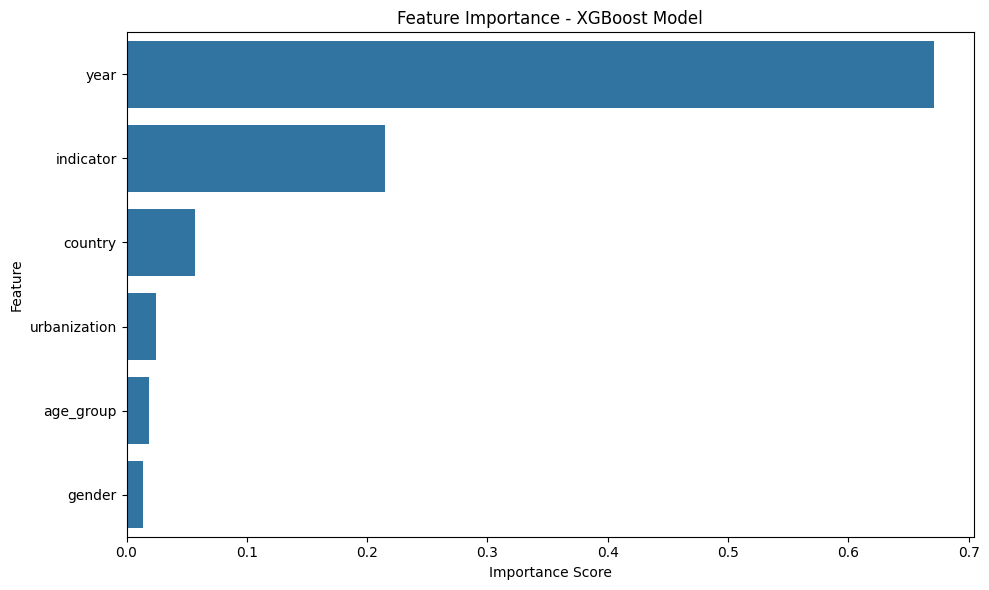

In [117]:
# VISUALIZE FEATURE IMPORTANCE
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# SHAP (SHapley Additive exPlanations)
Explainability for Financial Exclusion Modeling

In [119]:
# Install SHAP library (run once if needed)

!pip install shap

In [120]:
# IMPORT SHAP LIBRARY
import shap

# CREATE SHAP EXPLAINER
# The explainer learns how the model makes predictions

explainer = shap.Explainer(xgb_model)

# Generate SHAP values for test dataset

shap_values = explainer(X_test)

SHAP Summary Plot

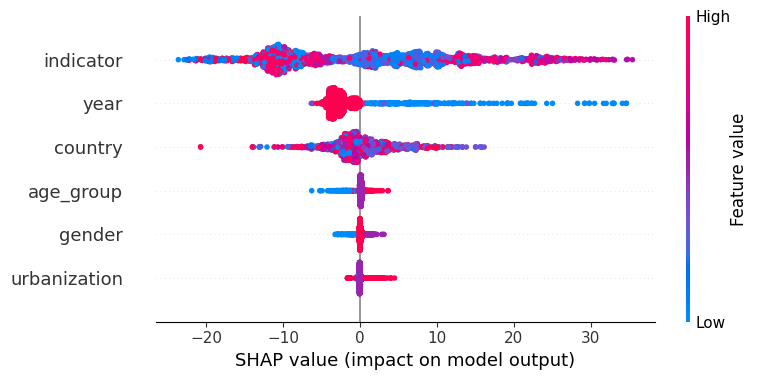

In [123]:
# SHAP SUMMARY PLOT
shap.summary_plot(
    shap_values,
    X_test
)

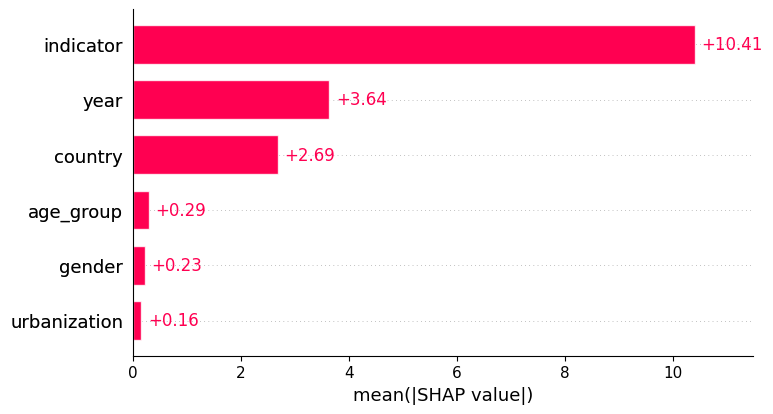

In [124]:
# SHAP FEATURE IMPORTANCE BAR PLOT
shap.plots.bar(shap_values

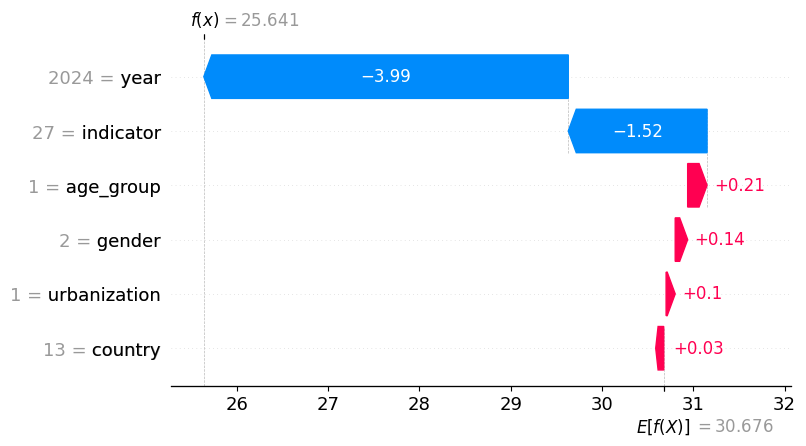

In [125]:
# SHAP WATERFALL PLOT
# Explain first prediction in test dataset

shap.plots.waterfall(shap_values[0])